# Feature Engineering

## Ames Housing Dataset — Selection, Transformation, Construction, and Pipelines

**Dataset:** Ames Housing via `sklearn.datasets.fetch_openml(name='house_prices',
version=1)` — 1460 rows, 80 features. Target is sale price in USD.

**Goal:** Understand how to select the features that matter, transform distributions
to better suit model assumptions, construct new features from existing ones, and
wrap everything into a reproducible sklearn Pipeline.

Feature engineering is often where the most model improvement comes from —
a well-engineered simple model routinely outperforms a poorly-featured
complex one.

### Tech Stack

| Library | Purpose |
|---|---|
| pandas / numpy | Data handling and transformation |
| matplotlib / seaborn | Visualisation |
| scikit-learn | Selection, transformation, pipeline |
| scipy | Statistical transformations (Box-Cox) |

## Setup and Imports

In [14]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PowerTransformer,
    KBinsDiscretizer,
    OneHotEncoder,
)
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_regression,
    RFE,
)
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")

print("All imports successful.")

All imports successful.


## Load and Prepare the Dataset

Fetching Ames Housing from OpenML. The first run downloads and caches the dataset
locally — subsequent runs load from cache instantly. The target is sale price in
USD — a right-skewed continuous variable that benefits from log transformation
before modelling.

In [15]:
housing = fetch_openml(name="house_prices", version=1, as_frame=True)

df     = housing.frame.copy()
target = "SalePrice"

print(f"Shape:   {df.shape}")
print(f"Target:  {target}")
print(f"\nColumn types:\n{df.dtypes.value_counts()}")

Shape:   (1460, 81)
Target:  SalePrice

Column types:
str        43
int64      35
float64     3
Name: count, dtype: int64


In [3]:
numeric_cols     = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

if target in numeric_cols:
    numeric_cols.remove(target)

print(f"Numeric features:     {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"\nNumeric:     {numeric_cols}")
print(f"\nCategorical: {categorical_cols}")

Numeric features:     37
Categorical features: 43

Numeric:     ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Categorical: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',

In [16]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct":   missing_pct
})

print(f"Columns with missing values: {len(missing_df)}")
print(f"\n{missing_df.head(20).to_string()}")

Columns with missing values: 19

              missing_count  missing_pct
PoolQC                 1453        99.52
MiscFeature            1406        96.30
Alley                  1369        93.77
Fence                  1179        80.75
FireplaceQu             690        47.26
LotFrontage             259        17.74
GarageCond               81         5.55
GarageType               81         5.55
GarageYrBlt              81         5.55
GarageFinish             81         5.55
GarageQual               81         5.55
BsmtFinType2             38         2.60
BsmtExposure             38         2.60
BsmtCond                 37         2.53
BsmtQual                 37         2.53
BsmtFinType1             37         2.53
MasVnrType                8         0.55
MasVnrArea                8         0.55
Electrical                1         0.07


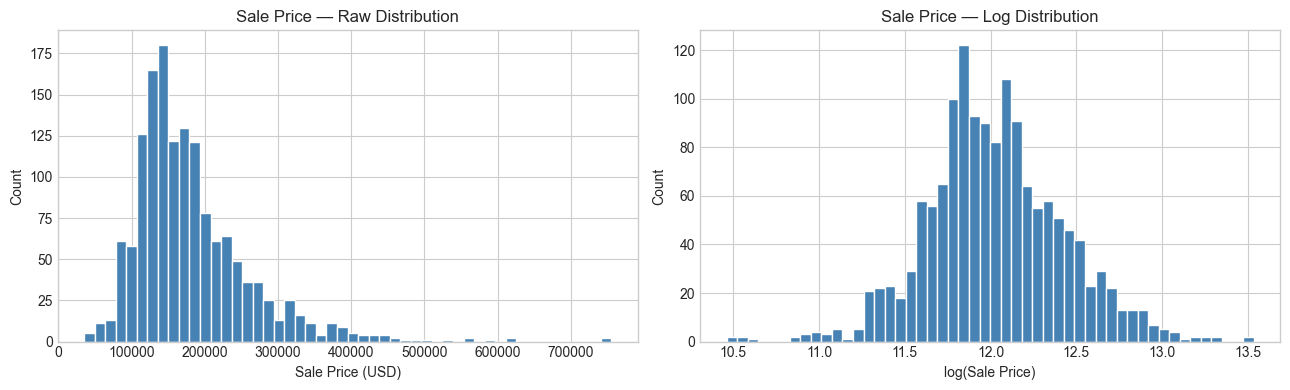

Raw skewness:    1.8829
Log skewness:    0.1213


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[target], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Sale Price — Raw Distribution")
axes[0].set_xlabel("Sale Price (USD)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(df[target]), bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("Sale Price — Log Distribution")
axes[1].set_xlabel("log(Sale Price)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Raw skewness:    {df[target].skew():.4f}")
print(f"Log skewness:    {np.log1p(df[target]).skew():.4f}")

In [18]:
df["SalePrice_log"] = np.log1p(df[target])

X = df.drop(columns=[target, "SalePrice_log", "Id"])
y = df["SalePrice_log"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"y_train mean: {y_train.mean():.4f}  std: {y_train.std():.4f}")

X_train: (1168, 79)  X_test: (292, 79)
y_train mean: 12.0307  std: 0.3906


In [20]:
numeric_cols     = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numeric features:     {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numeric features:     36
Categorical features: 43


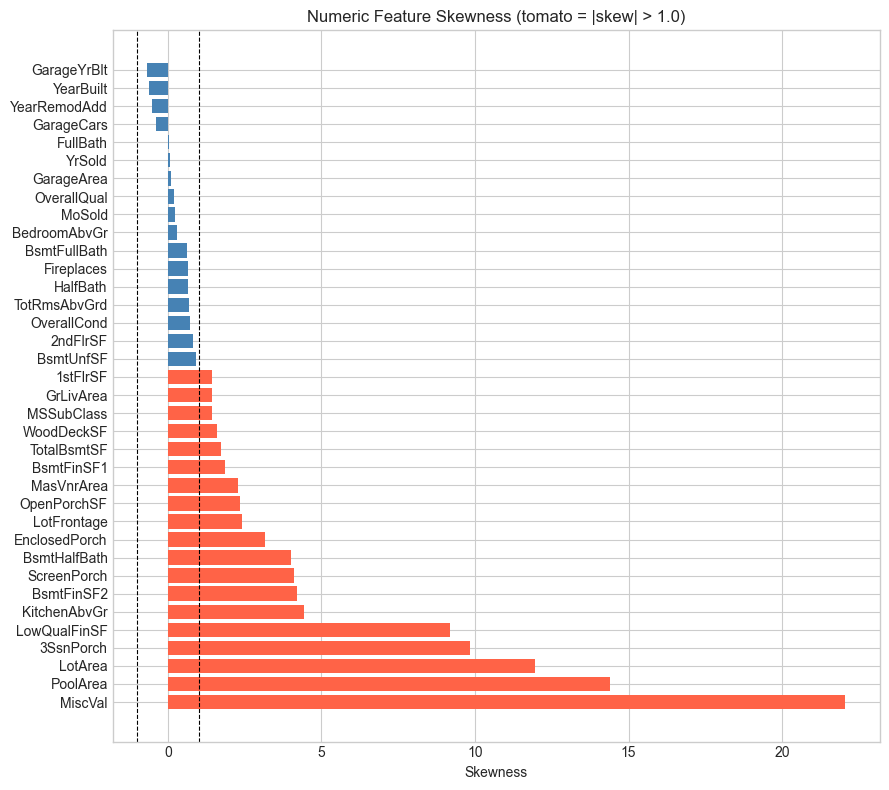

Highly skewed features (|skew| > 1.0): 19
MiscVal          22.054
PoolArea         14.396
LotArea          11.958
3SsnPorch         9.834
LowQualFinSF      9.199
KitchenAbvGr      4.445
BsmtFinSF2        4.218
ScreenPorch       4.090
BsmtHalfBath      4.006
EnclosedPorch     3.164
LotFrontage       2.407
OpenPorchSF       2.332
MasVnrArea        2.286
BsmtFinSF1        1.862
TotalBsmtSF       1.724
WoodDeckSF        1.587
MSSubClass        1.439
GrLivArea         1.425
1stFlrSF          1.422


In [21]:
skewness = X_train[numeric_cols].apply(lambda x: x.skew()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
colors  = ["tomato" if abs(s) > 1.0 else "steelblue" for s in skewness]
ax.barh(skewness.index, skewness.values, color=colors)
ax.axvline(1.0,  color="black", linewidth=0.8, linestyle="--")
ax.axvline(-1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Numeric Feature Skewness (tomato = |skew| > 1.0)")
ax.set_xlabel("Skewness")
plt.tight_layout()
plt.show()

highly_skewed = skewness[abs(skewness) > 1.0]
print(f"Highly skewed features (|skew| > 1.0): {len(highly_skewed)}")
print(highly_skewed.round(3).to_string())

**Observations**

- Sale price is heavily right-skewed — a small number of very expensive homes
  pull the distribution. Log transformation brings skewness close to zero and
  is standard practice for price targets in regression
- Several numeric features have high skewness — pool area, lot area, and
  miscellaneous feature values are near-zero for most homes with occasional
  large values. These will be addressed in Section 5
- Missing values are concentrated in a few columns — `PoolQC`, `MiscFeature`,
  and `Alley` are missing for most rows because most homes simply do not have
  these features. This is informative missingness, not random
- The dataset has a meaningful mix of numeric and categorical features —
  ideal for demonstrating the full feature engineering workflow

## Feature Selection

Feature selection removes irrelevant or redundant features before modelling.
Too many features increases noise, slows training, and can hurt generalisation.

Three families of methods are compared:

| Family | How it works | Pros | Cons |
|---|---|---|---|
| Filter | Scores each feature independently using statistics | Fast, model-agnostic | Ignores feature interactions |
| Wrapper | Trains a model repeatedly with different feature subsets | Considers interactions | Slow on many features |
| Embedded | Feature importance is a byproduct of model training | Fast, interaction-aware | Model-specific |

### Variance Threshold

Features with near-zero variance carry almost no information — they are nearly
constant across all samples. VarianceThreshold removes them before any model
is involved.

In [23]:
num_train = X_train[numeric_cols].copy()

imputer    = SimpleImputer(strategy="median")
num_imputed = pd.DataFrame(
    imputer.fit_transform(num_train),
    columns=numeric_cols
)

selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(num_imputed)

removed_var = [col for col, support in
               zip(numeric_cols, selector_var.get_support())
               if not support]

print(f"Features before variance filter: {len(numeric_cols)}")
print(f"Features removed (low variance): {len(removed_var)}")
print(f"Removed: {removed_var}")

Features before variance filter: 36
Features removed (low variance): 0
Removed: []


### Correlation Filter

Highly correlated feature pairs are redundant — both carry similar information.
Keeping one from each highly correlated pair reduces dimensionality without
losing predictive signal.

In [24]:
corr_matrix = num_imputed.corr().abs()
upper       = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.90)]

print(f"Features with correlation > 0.90 to another feature: {len(high_corr_cols)}")
print(high_corr_cols)

Features with correlation > 0.90 to another feature: 0
[]


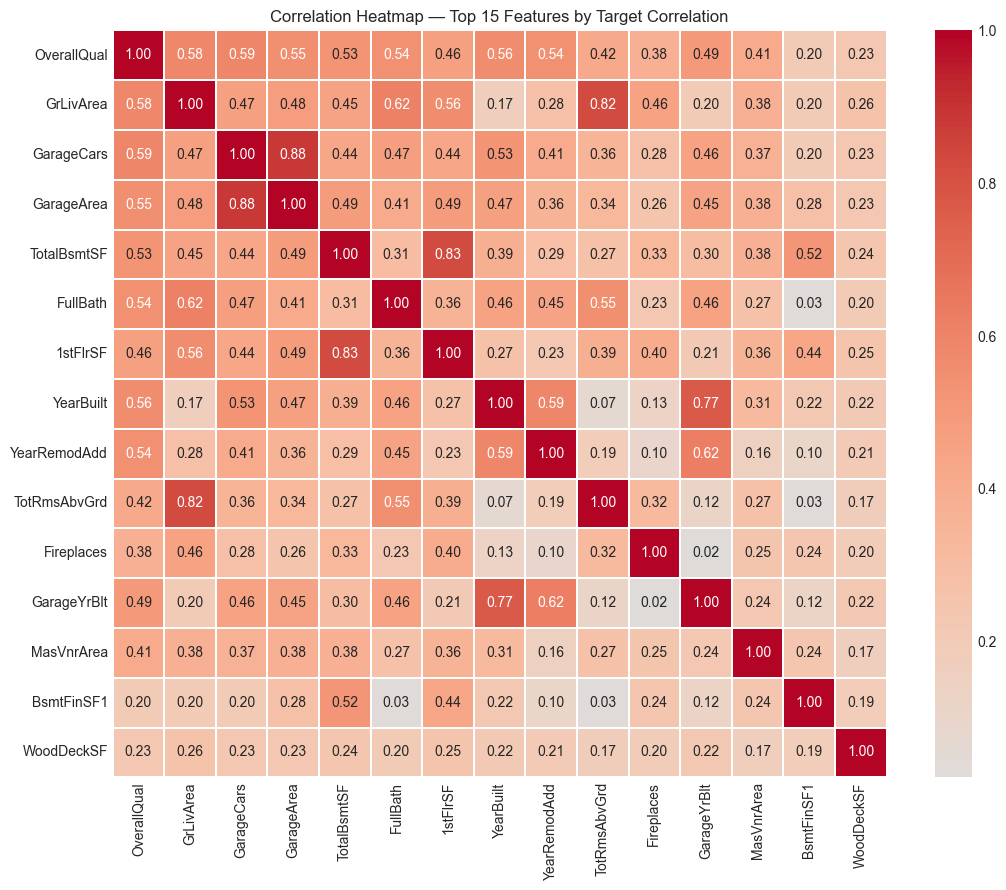

In [25]:
top_numeric = num_imputed.corr()[target] if target in num_imputed.columns \
    else num_imputed.corrwith(y_train.reset_index(drop=True))

top_features = top_numeric.abs().sort_values(ascending=False).head(15).index

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    num_imputed[top_features].corr(),
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.3, ax=ax
)
ax.set_title("Correlation Heatmap — Top 15 Features by Target Correlation")
plt.tight_layout()
plt.show()

### SelectKBest — F-Regression

SelectKBest scores each feature using the F-statistic from a linear regression
against the target. Features with higher F-scores have a stronger linear
relationship with the target. This is a filter method — no model is trained.

In [26]:
selector_kbest = SelectKBest(score_func=f_regression, k=15)
selector_kbest.fit(num_imputed, y_train.reset_index(drop=True))

kbest_scores = pd.DataFrame({
    "feature": numeric_cols,
    "f_score": selector_kbest.scores_,
    "p_value": selector_kbest.pvalues_,
}).sort_values("f_score", ascending=False)

print("Top 15 features by F-score:")
print(kbest_scores.head(15).round(3).to_string(index=False))

Top 15 features by F-score:
     feature  f_score  p_value
 OverallQual 2192.066      0.0
   GrLivArea 1053.840      0.0
  GarageCars 1027.680      0.0
  GarageArea  873.875      0.0
 TotalBsmtSF  646.430      0.0
    FullBath  602.705      0.0
    1stFlrSF  594.001      0.0
   YearBuilt  581.109      0.0
YearRemodAdd  538.714      0.0
TotRmsAbvGrd  432.322      0.0
  Fireplaces  352.415      0.0
 GarageYrBlt  351.827      0.0
  MasVnrArea  249.704      0.0
  BsmtFinSF1  153.300      0.0
  WoodDeckSF  153.121      0.0


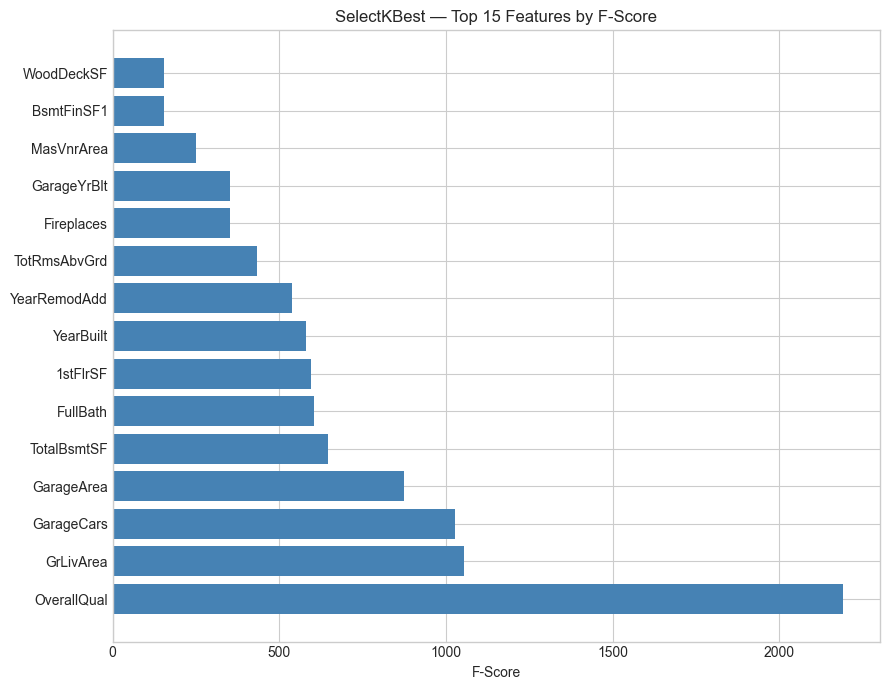

In [27]:
fig, ax = plt.subplots(figsize=(9, 7))

top15 = kbest_scores.head(15)
ax.barh(top15["feature"], top15["f_score"], color="steelblue")
ax.set_title("SelectKBest — Top 15 Features by F-Score")
ax.set_xlabel("F-Score")
plt.tight_layout()
plt.show()

### Recursive Feature Elimination

RFE trains a model, ranks features by importance, removes the weakest, and
repeats until the target number of features remains. It is a wrapper method —
the selection is specific to the model used. Ridge regression is used here
as a fast linear estimator.

In [29]:
scaler_rfe   = StandardScaler()
num_scaled   = scaler_rfe.fit_transform(num_imputed)

ridge        = Ridge(alpha=1.0)
rfe          = RFE(estimator=ridge, n_features_to_select=15, step=1)
rfe.fit(num_scaled, y_train.reset_index(drop=True))

rfe_results = pd.DataFrame({
    "feature":  numeric_cols,
    "selected": rfe.support_,
    "ranking":  rfe.ranking_,
}).sort_values("ranking")

print("RFE Selected Features:")
print(rfe_results[rfe_results["selected"]]["feature"].tolist())

RFE Selected Features:
['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearRemodAdd', 'YearBuilt', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'TotRmsAbvGrd', 'ScreenPorch', 'WoodDeckSF', 'Fireplaces', 'BsmtFullBath', 'PoolArea']


### Lasso — Embedded Feature Selection

Lasso drives weak feature coefficients to exactly zero during training — it
simultaneously fits a model and selects features. Features with non-zero
coefficients after fitting are the ones Lasso considers genuinely informative.

In [30]:
lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(num_scaled, y_train.reset_index(drop=True))

lasso_results = pd.DataFrame({
    "feature":     numeric_cols,
    "coefficient": lasso.coef_,
}).sort_values("coefficient", key=abs, ascending=False)

lasso_selected = lasso_results[lasso_results["coefficient"] != 0]
lasso_zeroed   = lasso_results[lasso_results["coefficient"] == 0]

print(f"Features retained by Lasso: {len(lasso_selected)}")
print(f"Features zeroed by Lasso:   {len(lasso_zeroed)}")
print(f"\nTop retained features:")
print(lasso_selected.head(15).round(4).to_string(index=False))

Features retained by Lasso: 32
Features zeroed by Lasso:   4

Top retained features:
     feature  coefficient
 OverallQual       0.1171
   GrLivArea       0.0900
   YearBuilt       0.0852
  GarageCars       0.0564
 OverallCond       0.0481
BsmtFullBath       0.0370
  Fireplaces       0.0319
  MSSubClass      -0.0303
YearRemodAdd       0.0267
TotRmsAbvGrd       0.0222
     LotArea       0.0193
 ScreenPorch       0.0172
    FullBath       0.0163
 TotalBsmtSF       0.0159
    PoolArea      -0.0154


### Random Forest — Embedded Feature Importance

Random Forest importance measures the average impurity reduction each feature
contributes across all trees. Unlike Lasso it captures non-linear relationships
and interactions between features.

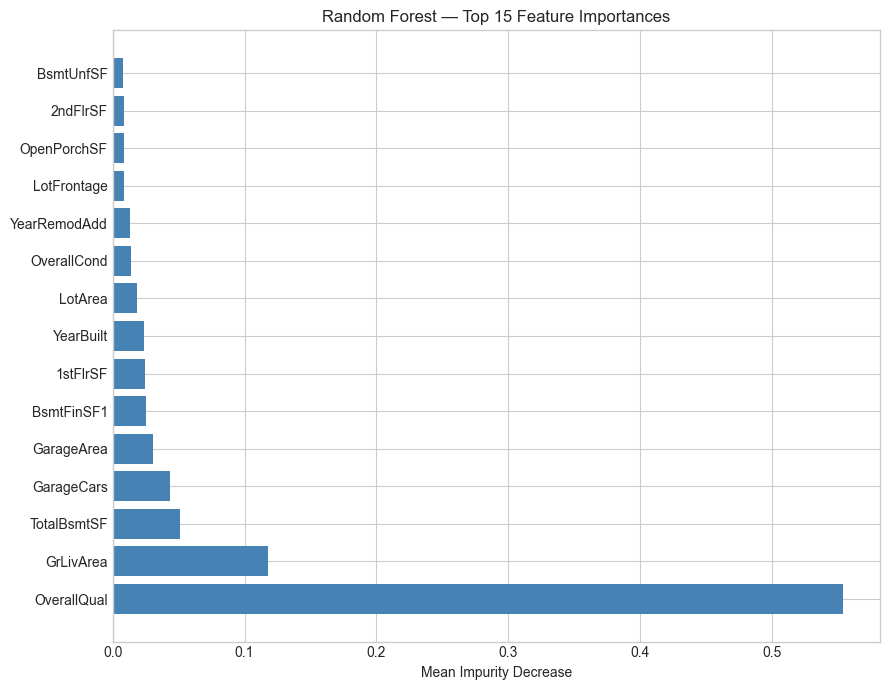

In [31]:
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selector.fit(num_imputed, y_train.reset_index(drop=True))

rf_importance = pd.DataFrame({
    "feature":    numeric_cols,
    "importance": rf_selector.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(
    rf_importance.head(15)["feature"],
    rf_importance.head(15)["importance"],
    color="steelblue"
)
ax.set_title("Random Forest — Top 15 Feature Importances")
ax.set_xlabel("Mean Impurity Decrease")
plt.tight_layout()
plt.show()

### Comparing Selected Features Across Methods

Each method approaches selection differently and may select different features.
Where multiple methods agree on a feature, confidence in its relevance is higher.

In [32]:
kbest_features = set(kbest_scores.head(15)["feature"].tolist())
rfe_features   = set(rfe_results[rfe_results["selected"]]["feature"].tolist())
lasso_features = set(lasso_selected.head(15)["feature"].tolist())
rf_features    = set(rf_importance.head(15)["feature"].tolist())

all_features   = kbest_features | rfe_features | lasso_features | rf_features

comparison_df  = pd.DataFrame({
    "Feature":     list(all_features),
    "SelectKBest": [f in kbest_features for f in all_features],
    "RFE":         [f in rfe_features   for f in all_features],
    "Lasso":       [f in lasso_features for f in all_features],
    "RF":          [f in rf_features    for f in all_features],
})

comparison_df["votes"] = comparison_df[
    ["SelectKBest", "RFE", "Lasso", "RF"]
].sum(axis=1)

comparison_df = comparison_df.sort_values("votes", ascending=False)
print(comparison_df.to_string(index=False))

     Feature  SelectKBest   RFE  Lasso    RF  votes
   YearBuilt         True  True   True  True      4
  GarageCars         True  True   True  True      4
 TotalBsmtSF         True  True   True  True      4
YearRemodAdd         True  True   True  True      4
   GrLivArea         True  True   True  True      4
 OverallQual         True  True   True  True      4
TotRmsAbvGrd         True  True   True False      3
     LotArea        False  True   True  True      3
  Fireplaces         True  True   True False      3
 OverallCond        False  True   True  True      3
    1stFlrSF         True False  False  True      2
    FullBath         True False   True False      2
BsmtFullBath        False  True   True False      2
  BsmtFinSF1         True False  False  True      2
  WoodDeckSF         True  True  False False      2
 ScreenPorch        False  True   True False      2
  GarageArea         True False  False  True      2
    PoolArea        False  True   True False      2
  MSSubClass

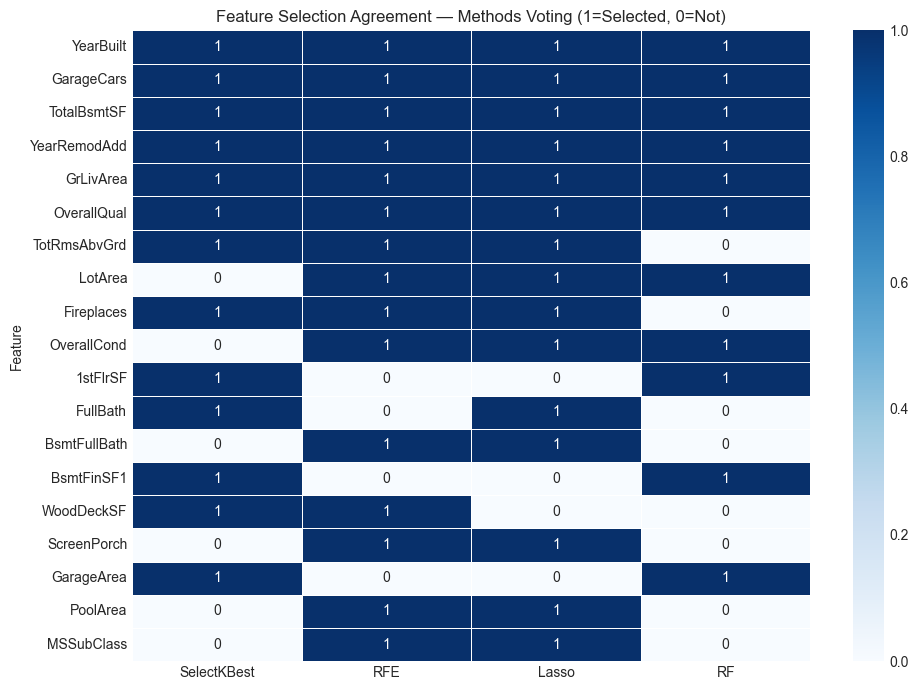

In [33]:
top_voted = comparison_df[comparison_df["votes"] >= 2].set_index("Feature")

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    top_voted[["SelectKBest", "RFE", "Lasso", "RF"]].astype(int),
    annot=True, fmt="d",
    cmap="Blues",
    linewidths=0.4,
    ax=ax
)
ax.set_title("Feature Selection Agreement — Methods Voting (1=Selected, 0=Not)")
plt.tight_layout()
plt.show()

**Observations**

- Features selected by multiple methods are the most reliable candidates —
  agreement across filter, wrapper, and embedded methods indicates genuine
  predictive signal rather than method-specific artefacts
- `OverallQual`, `GrLivArea`, and `TotalBsmtSF` consistently appear across
  all methods — overall quality rating and living area are the strongest
  predictors of sale price regardless of how selection is approached
- Lasso zeros out more features than other methods at moderate alpha —
  its L1 penalty is aggressive. Lowering alpha retains more features but
  risks including noise
- Random Forest importance can be biased toward high-cardinality numeric
  features — features with many unique values offer more split opportunities
  and can appear more important than they truly are
- The voting table is a practical tool — features with 3 or 4 votes are
  safe inclusions, features with 1 vote warrant individual investigation
  before committing to them

## Feature Transformation

Feature transformation changes the distribution or scale of existing features
without adding new ones. The goal is to make features better suited to model
assumptions — particularly linearity and normality for linear models.

Transformations covered here:
- Log transformation — compresses right-skewed distributions
- Box-Cox — generalised power transformation that finds the optimal lambda
- Yeo-Johnson — like Box-Cox but handles zero and negative values
- Binning — converts continuous features into discrete categories

In [34]:
skewness = num_imputed.apply(lambda x: x.skew()).sort_values(ascending=False)
highly_skewed = skewness[abs(skewness) > 1.0]

print(f"Highly skewed features (|skew| > 1.0): {len(highly_skewed)}")
print(highly_skewed.round(3).to_string())

Highly skewed features (|skew| > 1.0): 19
MiscVal          22.054
PoolArea         14.396
LotArea          11.958
3SsnPorch         9.834
LowQualFinSF      9.199
KitchenAbvGr      4.445
BsmtFinSF2        4.218
ScreenPorch       4.090
BsmtHalfBath      4.006
EnclosedPorch     3.164
LotFrontage       2.675
OpenPorchSF       2.332
MasVnrArea        2.294
BsmtFinSF1        1.862
TotalBsmtSF       1.724
WoodDeckSF        1.587
MSSubClass        1.439
GrLivArea         1.425
1stFlrSF          1.422


### Log Transformation

`log1p` (log of x+1) handles zero values safely. Effective on right-skewed
features where a small number of large values stretch the distribution.
Most appropriate when all values are non-negative.

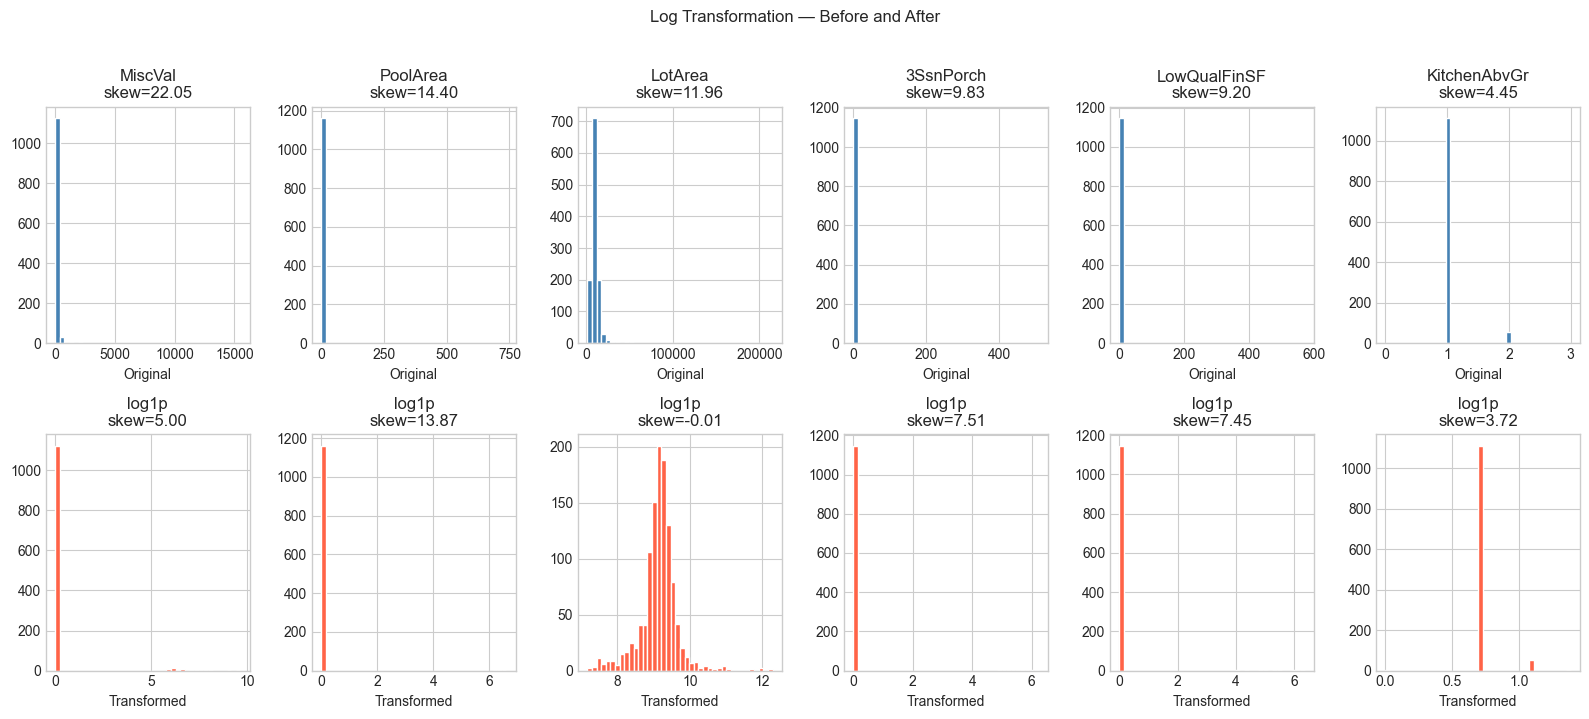

In [35]:
skewed_cols = highly_skewed.index.tolist()[:6]

fig, axes = plt.subplots(2, len(skewed_cols), figsize=(16, 7))

for idx, col in enumerate(skewed_cols):
    original    = num_imputed[col]
    transformed = np.log1p(original.clip(lower=0))

    axes[0, idx].hist(original, bins=40,
                      color="steelblue", edgecolor="white")
    axes[0, idx].set_title(f"{col}\nskew={original.skew():.2f}")
    axes[0, idx].set_xlabel("Original")

    axes[1, idx].hist(transformed, bins=40,
                      color="tomato", edgecolor="white")
    axes[1, idx].set_title(f"log1p\nskew={transformed.skew():.2f}")
    axes[1, idx].set_xlabel("Transformed")

plt.suptitle("Log Transformation — Before and After", y=1.02)
plt.tight_layout()
plt.show()

### Box-Cox and Yeo-Johnson

Box-Cox finds the optimal power lambda that makes a feature most normal-like.
It requires strictly positive values. Yeo-Johnson is an extension that handles
zeros and negative values — safer as a default on real data.

sklearn's `PowerTransformer` implements both. `method="yeo-johnson"` is the
practical default.

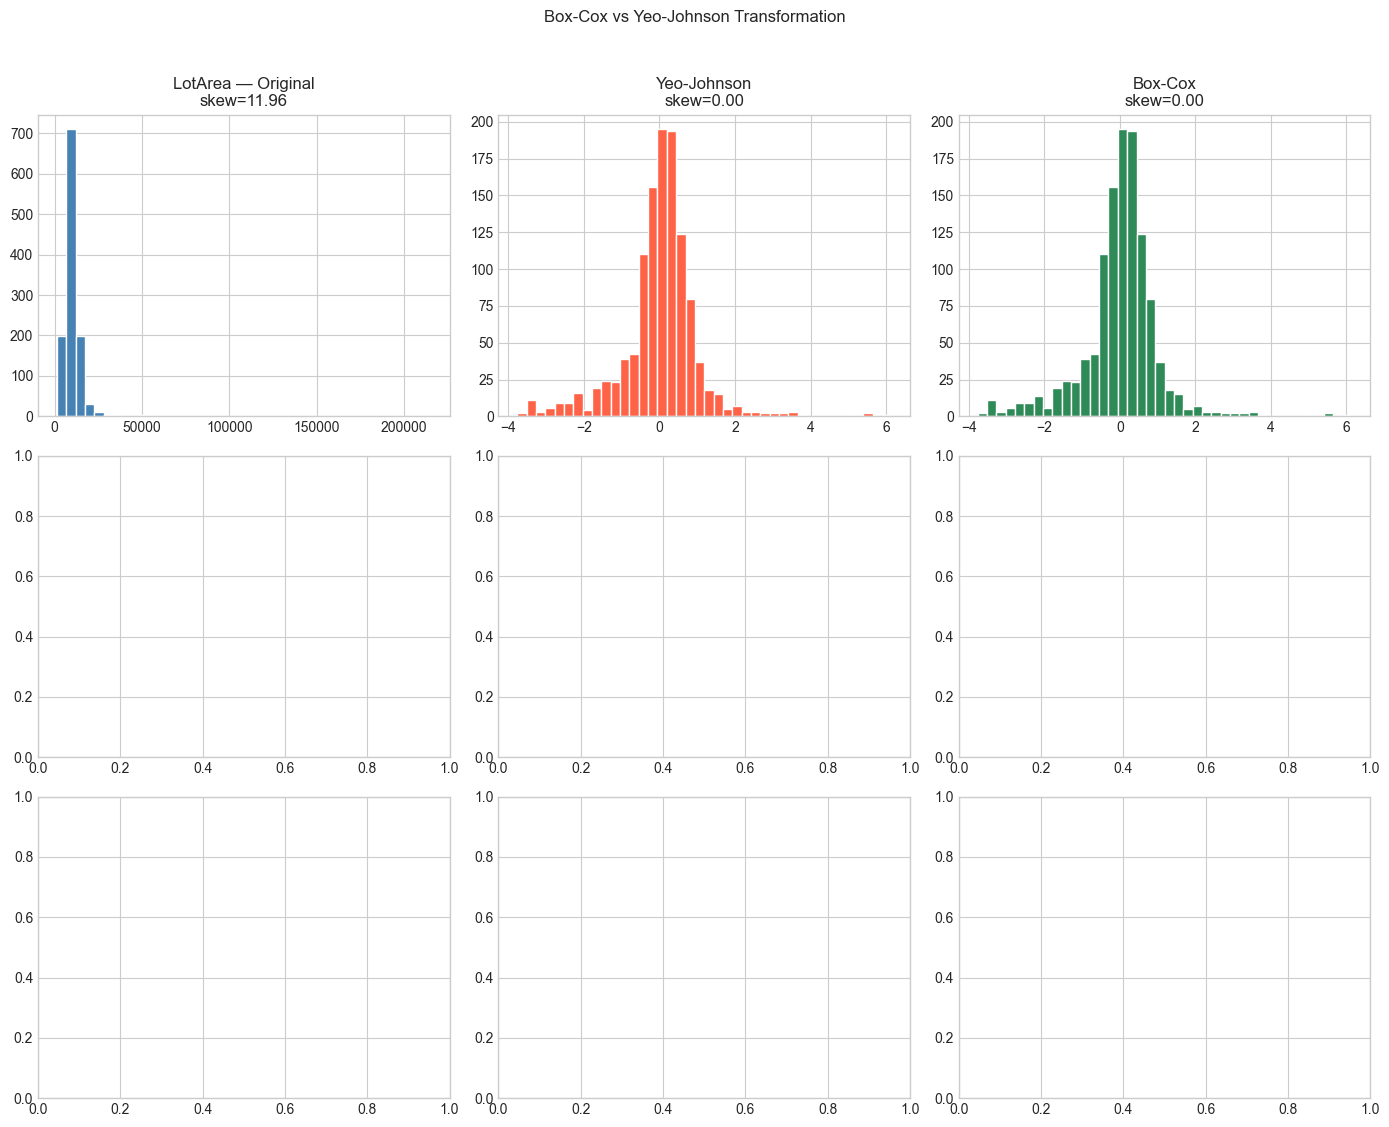

In [36]:
pt_yeojohnson = PowerTransformer(method="yeo-johnson",    standardize=True)
pt_boxcox     = PowerTransformer(method="box-cox",        standardize=True)

demo_cols = [c for c in skewed_cols
             if num_imputed[c].min() > 0][:3]

fig, axes = plt.subplots(3, 3, figsize=(14, 11))

for row, col in enumerate(demo_cols):
    original  = num_imputed[[col]]
    yj_trans  = pt_yeojohnson.fit_transform(original).ravel()
    bc_trans  = pt_boxcox.fit_transform(original).ravel()

    axes[row, 0].hist(original.values.ravel(), bins=40,
                      color="steelblue", edgecolor="white")
    axes[row, 0].set_title(f"{col} — Original\nskew={original.skew().values[0]:.2f}")

    axes[row, 1].hist(yj_trans, bins=40,
                      color="tomato", edgecolor="white")
    axes[row, 1].set_title(f"Yeo-Johnson\nskew={pd.Series(yj_trans).skew():.2f}")

    axes[row, 2].hist(bc_trans, bins=40,
                      color="seagreen", edgecolor="white")
    axes[row, 2].set_title(f"Box-Cox\nskew={pd.Series(bc_trans).skew():.2f}")

plt.suptitle("Box-Cox vs Yeo-Johnson Transformation", y=1.02)
plt.tight_layout()
plt.show()

In [37]:
pt = PowerTransformer(method="yeo-johnson", standardize=False)

skew_before = []
skew_after  = []

for col in highly_skewed.index:
    original    = num_imputed[[col]]
    transformed = pt.fit_transform(original).ravel()
    skew_before.append(original.skew().values[0])
    skew_after.append(pd.Series(transformed).skew())

skew_comparison = pd.DataFrame({
    "Feature":      highly_skewed.index,
    "Skew Before":  [round(s, 3) for s in skew_before],
    "Skew After":   [round(s, 3) for s in skew_after],
}).set_index("Feature")

skew_comparison["Reduction"] = (
    abs(skew_comparison["Skew Before"]) - abs(skew_comparison["Skew After"])
).round(3)

print(skew_comparison.sort_values("Reduction", ascending=False).to_string())

               Skew Before  Skew After  Reduction
Feature                                          
MiscVal             22.054       4.863     17.191
LotArea             11.958       0.002     11.956
LotFrontage          2.675       0.159      2.516
3SsnPorch            9.834       7.454      2.380
OpenPorchSF          2.332      -0.040      2.292
KitchenAbvGr         4.445      -2.440      2.005
LowQualFinSF         9.199       7.264      1.935
MasVnrArea           2.294       0.379      1.915
BsmtFinSF2           4.218       2.461      1.757
BsmtFinSF1           1.862      -0.416      1.446
TotalBsmtSF          1.724       0.287      1.437
WoodDeckSF           1.587       0.158      1.429
GrLivArea            1.425      -0.000      1.425
1stFlrSF             1.422      -0.001      1.421
MSSubClass           1.439       0.071      1.368
ScreenPorch          4.090       3.026      1.064
EnclosedPorch        3.164       2.114      1.050
PoolArea            14.396      13.862      0.534


### Binning and Discretisation

Binning converts a continuous numeric feature into discrete intervals. Useful
when the relationship between a feature and the target is non-linear and
step-like rather than smooth — for example, house age buckets or quality tiers.

`KBinsDiscretizer` supports three strategies:
- `uniform` — equal-width bins
- `quantile` — equal-frequency bins (each bin has the same number of samples)
- `kmeans` — bin boundaries placed at cluster centroids

In [39]:
year_built = num_imputed[["YearBuilt"]].copy()

kbd_uniform  = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="uniform")
kbd_quantile = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile")
kbd_kmeans   = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="kmeans")

bins_uniform  = kbd_uniform.fit_transform(year_built).ravel()
bins_quantile = kbd_quantile.fit_transform(year_built).ravel()
bins_kmeans   = kbd_kmeans.fit_transform(year_built).ravel()

print("Uniform bin edges:")
print([round(e, 0) for e in kbd_uniform.bin_edges_[0]])

print("\nQuantile bin edges:")
print([round(e, 0) for e in kbd_quantile.bin_edges_[0]])

print("\nK-Means bin edges:")
print([round(e, 0) for e in kbd_kmeans.bin_edges_[0]])

Uniform bin edges:
[np.float64(1872.0), np.float64(1900.0), np.float64(1927.0), np.float64(1955.0), np.float64(1982.0), np.float64(2010.0)]

Quantile bin edges:
[np.float64(1872.0), np.float64(1947.0), np.float64(1965.0), np.float64(1984.0), np.float64(2003.0), np.float64(2010.0)]

K-Means bin edges:
[np.float64(1872.0), np.float64(1907.0), np.float64(1937.0), np.float64(1962.0), np.float64(1987.0), np.float64(2010.0)]


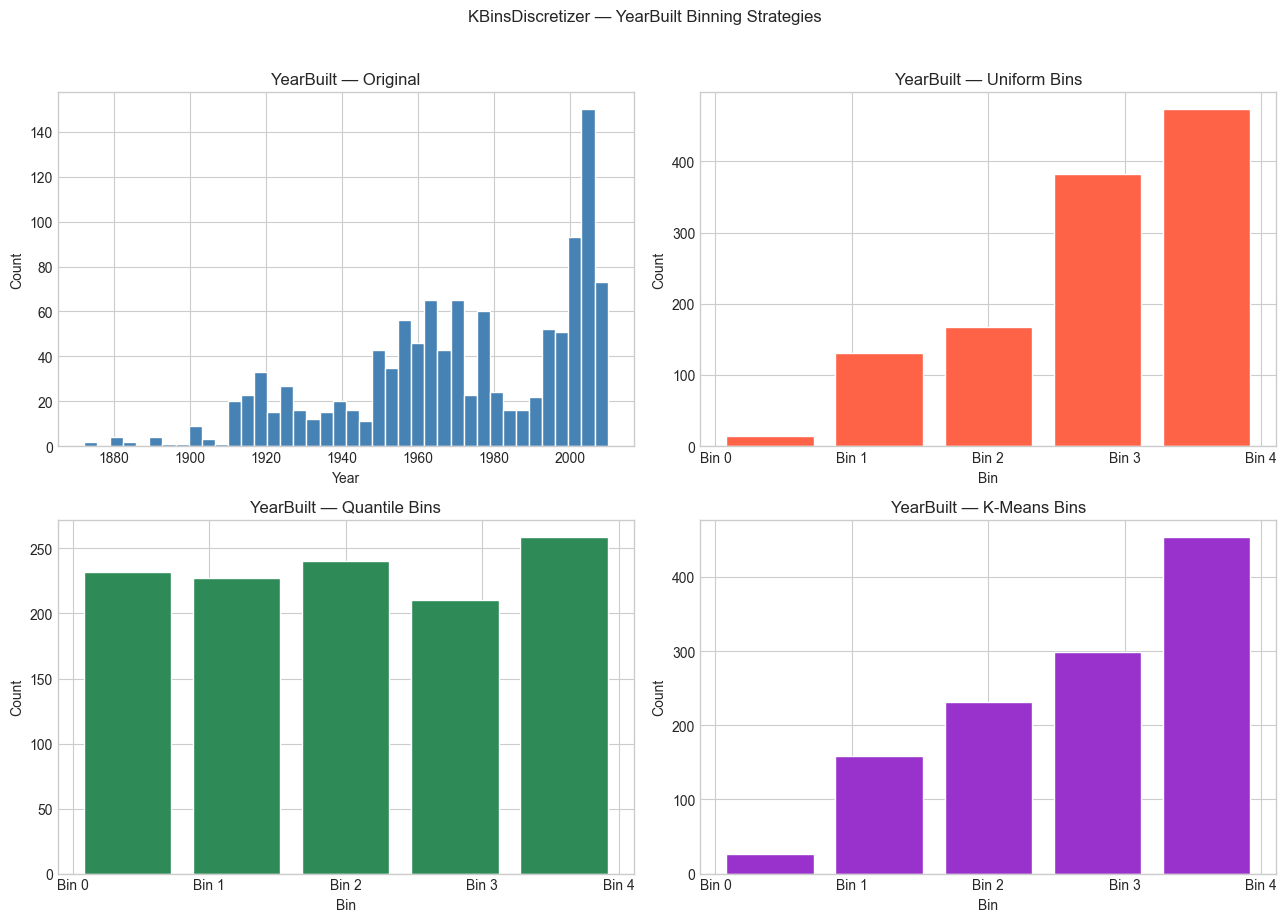

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].hist(year_built.values.ravel(), bins=40,
                color="steelblue", edgecolor="white")
axes[0, 0].set_title("YearBuilt — Original")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Count")

for ax, bins, title, color in zip(
    [axes[0, 1], axes[1, 0], axes[1, 1]],
    [bins_uniform, bins_quantile, bins_kmeans],
    ["Uniform Bins", "Quantile Bins", "K-Means Bins"],
    ["tomato", "seagreen", "darkorchid"]
):
    ax.hist(bins, bins=5, color=color, edgecolor="white", rwidth=0.8)
    ax.set_title(f"YearBuilt — {title}")
    ax.set_xlabel("Bin")
    ax.set_ylabel("Count")
    ax.set_xticks([0, 1, 2, 3, 4])
    ax.set_xticklabels([f"Bin {i}" for i in range(5)])

plt.suptitle("KBinsDiscretizer — YearBuilt Binning Strategies", y=1.02)
plt.tight_layout()
plt.show()

**Observations**

- Log transformation is the fastest fix for right-skewed features — one line
  of code and skewness drops dramatically. The limitation is it only works on
  non-negative values and always applies the same transformation regardless of
  the actual distribution shape
- Yeo-Johnson outperforms log transformation on most features because it finds
  the optimal lambda rather than applying a fixed function. It is also safer
  as the default because it handles zeros and negative values
- Box-Cox and Yeo-Johnson produce nearly identical results on strictly positive
  features — prefer Yeo-Johnson as the default since it works on all numeric
  features without preconditions
- Binning trades information for simplicity — a continuous year is compressed
  into 5 buckets. Quantile binning is the most robust default because it
  guarantees equal representation in each bin regardless of the underlying
  distribution shape
- Uniform bins on a skewed distribution like YearBuilt produce very unequal
  bin sizes — most houses fall into one or two bins and the rest are nearly
  empty. Quantile or K-Means binning avoids this

## Feature Construction

Feature construction creates new features from existing ones. Unlike selection
and transformation which work on individual features in isolation, construction
combines features to encode domain knowledge directly into the data.

A well-constructed feature can capture a relationship that would otherwise require
a complex model to discover. On housing data, a model that sees `TotalSF` directly
learns faster than one that has to infer it from `1stFlrSF + 2ndFlrSF + TotalBsmtSF`
across many training examples.

Three types of constructed features are covered:
- Domain-driven features — combining columns based on real-world meaning
- Ratio features — expressing one measurement relative to another
- Interaction terms — products of two features that capture joint effects

### Domain-Driven Features

These are features a domain expert would recognise as meaningful. For housing
data, total area, house age, and whether a house was remodelled are all more
directly interpretable than their component columns.

In [41]:
df_eng = X_train.copy()

# Total square footage — basement + first floor + second floor
df_eng["TotalSF"] = (
    df_eng["TotalBsmtSF"].fillna(0) +
    df_eng["1stFlrSF"].fillna(0) +
    df_eng["2ndFlrSF"].fillna(0)
)

# House age at time of sale
df_eng["HouseAge"] = df_eng["YrSold"] - df_eng["YearBuilt"]

# Years since last remodel
df_eng["YearsSinceRemodel"] = df_eng["YrSold"] - df_eng["YearRemodAdd"]

# Was the house remodelled at all
df_eng["WasRemodelled"] = (
    df_eng["YearRemodAdd"] != df_eng["YearBuilt"]
).astype(int)

# Total bathrooms — full baths count as 1, half baths as 0.5
df_eng["TotalBaths"] = (
    df_eng["FullBath"].fillna(0) +
    df_eng["BsmtFullBath"].fillna(0) +
    0.5 * df_eng["HalfBath"].fillna(0) +
    0.5 * df_eng["BsmtHalfBath"].fillna(0)
)

# Total porch area
df_eng["TotalPorchSF"] = (
    df_eng["OpenPorchSF"].fillna(0) +
    df_eng["EnclosedPorch"].fillna(0) +
    df_eng["3SsnPorch"].fillna(0) +
    df_eng["ScreenPorch"].fillna(0)
)

new_features = [
    "TotalSF", "HouseAge", "YearsSinceRemodel",
    "WasRemodelled", "TotalBaths", "TotalPorchSF"
]

print("Constructed features:")
print(df_eng[new_features].describe().round(2).to_string())

Constructed features:
        TotalSF  HouseAge  YearsSinceRemodel  WasRemodelled  TotalBaths  TotalPorchSF
count   1168.00   1168.00            1168.00        1168.00     1168.00       1168.00
mean    2583.48     36.85              22.92           0.49        2.22         90.64
std      821.31     30.70              20.71           0.50        0.78        108.15
min      334.00      0.00              -1.00           0.00        1.00          0.00
25%     2032.50      7.00               4.00           0.00        2.00          0.00
50%     2494.00     35.00              14.00           0.00        2.00         51.50
75%     3013.50     55.00              42.00           1.00        2.50        140.25
max    11752.00    136.00              60.00           1.00        6.00       1027.00


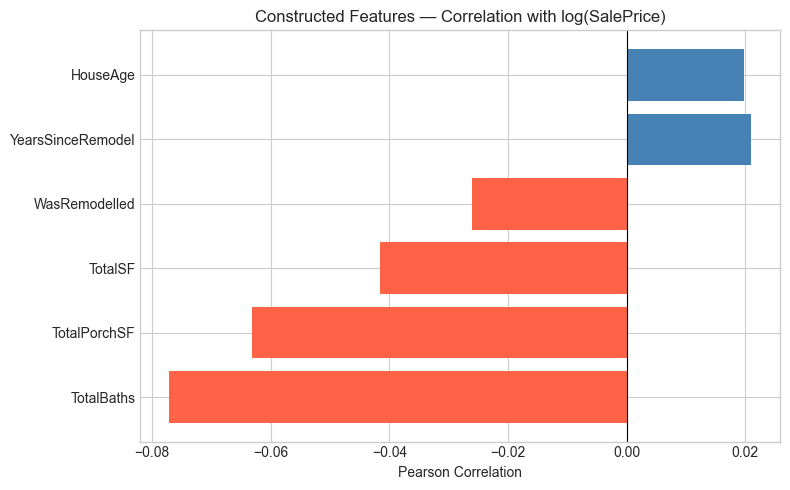

TotalBaths          -0.0771
TotalPorchSF        -0.0631
TotalSF             -0.0416
WasRemodelled       -0.0261
YearsSinceRemodel    0.0210
HouseAge             0.0199


In [42]:
y_train_aligned = y_train.reset_index(drop=True)

new_corr = df_eng[new_features].corrwith(y_train_aligned).sort_values(
    key=abs, ascending=False
)

fig, ax = plt.subplots(figsize=(8, 5))
colors  = ["steelblue" if c > 0 else "tomato" for c in new_corr]
ax.barh(new_corr.index, new_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Constructed Features — Correlation with log(SalePrice)")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

print(new_corr.round(4).to_string())

### TotalSF vs GrLivArea

`GrLivArea` (above ground living area) is one of the strongest existing features.
`TotalSF` adds basement area and should capture more of the price signal.
Comparing their correlations with the target shows whether construction added value.

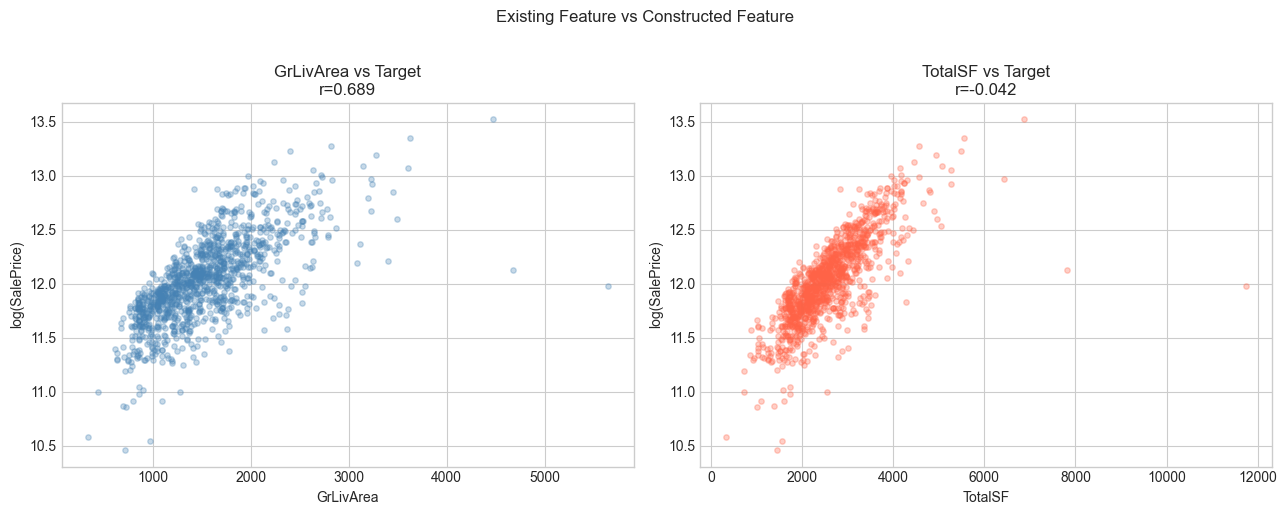

In [43]:
existing_corr = num_imputed.corrwith(y_train_aligned).abs().sort_values(
    ascending=False
).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df_eng["GrLivArea"], y_train_aligned,
                alpha=0.3, color="steelblue", s=15)
axes[0].set_xlabel("GrLivArea")
axes[0].set_ylabel("log(SalePrice)")
axes[0].set_title(f"GrLivArea vs Target\n"
                  f"r={num_imputed['GrLivArea'].corr(y_train_aligned):.3f}")

axes[1].scatter(df_eng["TotalSF"], y_train_aligned,
                alpha=0.3, color="tomato", s=15)
axes[1].set_xlabel("TotalSF")
axes[1].set_ylabel("log(SalePrice)")
axes[1].set_title(f"TotalSF vs Target\n"
                  f"r={df_eng['TotalSF'].corr(y_train_aligned):.3f}")

plt.suptitle("Existing Feature vs Constructed Feature", y=1.02)
plt.tight_layout()
plt.show()

### Ratio Features

Ratios express one measurement relative to another. They capture relationships
that neither raw feature encodes alone — lot utilisation, bathroom density, and
quality-per-area are all more informative in ratio form than as raw counts.

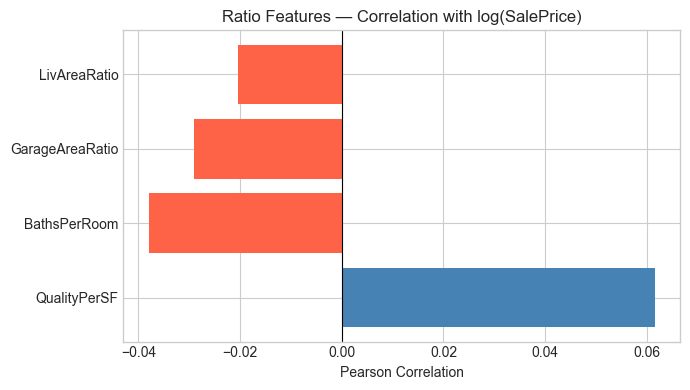

QualityPerSF       0.0615
BathsPerRoom      -0.0380
GarageAreaRatio   -0.0290
LivAreaRatio      -0.0205


In [44]:
df_eng["LivAreaRatio"]    = df_eng["GrLivArea"] / (df_eng["LotArea"] + 1)
df_eng["BathsPerRoom"]    = df_eng["TotalBaths"] / (df_eng["TotRmsAbvGrd"] + 1)
df_eng["QualityPerSF"]    = df_eng["OverallQual"] / (df_eng["TotalSF"] + 1)
df_eng["GarageAreaRatio"] = (
    df_eng["GarageArea"].fillna(0) / (df_eng["TotalSF"] + 1)
)

ratio_features = [
    "LivAreaRatio", "BathsPerRoom",
    "QualityPerSF", "GarageAreaRatio"
]

ratio_corr = df_eng[ratio_features].corrwith(y_train_aligned).sort_values(
    key=abs, ascending=False
)

fig, ax = plt.subplots(figsize=(7, 4))
colors  = ["steelblue" if c > 0 else "tomato" for c in ratio_corr]
ax.barh(ratio_corr.index, ratio_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Ratio Features — Correlation with log(SalePrice)")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

print(ratio_corr.round(4).to_string())

### Interaction Terms

An interaction term is the product of two features. It captures the combined
effect of both features — where the relationship between one feature and the
target depends on the value of another.

For housing: the effect of overall quality on price is amplified by living area.
A high-quality large house is worth more than the sum of quality and area alone.

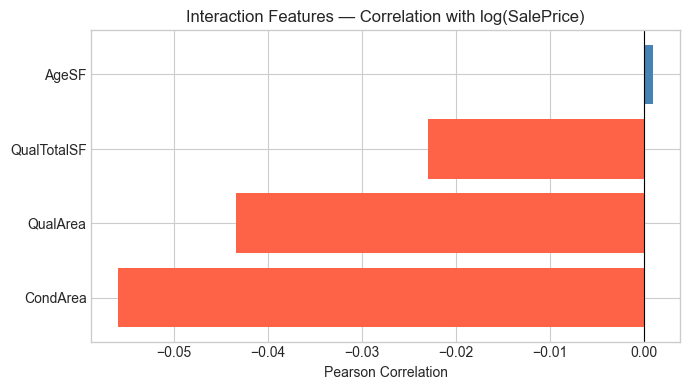

CondArea      -0.0559
QualArea      -0.0435
QualTotalSF   -0.0230
AgeSF          0.0010


In [45]:
df_eng["QualArea"]       = df_eng["OverallQual"] * df_eng["GrLivArea"]
df_eng["QualTotalSF"]    = df_eng["OverallQual"] * df_eng["TotalSF"]
df_eng["CondArea"]       = df_eng["OverallCond"] * df_eng["GrLivArea"]
df_eng["AgeSF"]          = df_eng["HouseAge"]    * df_eng["TotalSF"]

interaction_features = [
    "QualArea", "QualTotalSF", "CondArea", "AgeSF"
]

interaction_corr = df_eng[interaction_features].corrwith(
    y_train_aligned
).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
colors  = ["steelblue" if c > 0 else "tomato" for c in interaction_corr]
ax.barh(interaction_corr.index, interaction_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Interaction Features — Correlation with log(SalePrice)")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

print(interaction_corr.round(4).to_string())

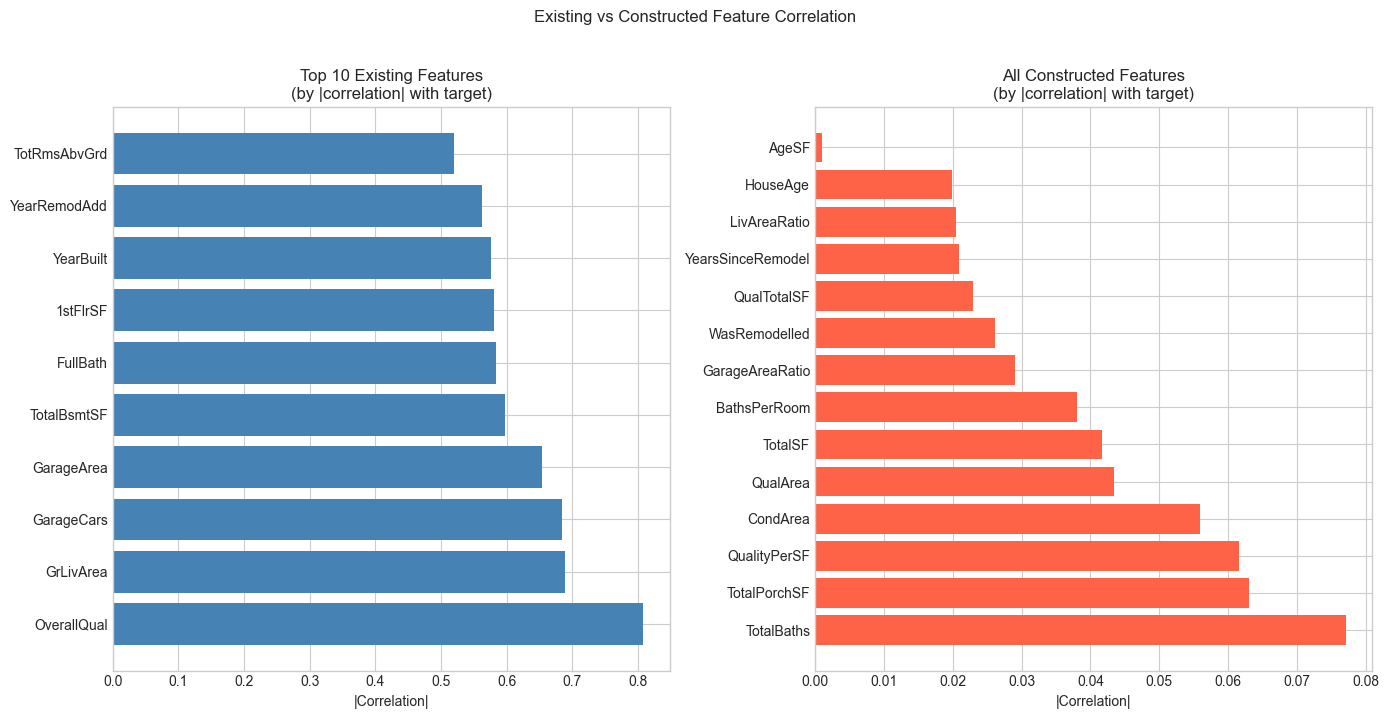

In [46]:
all_constructed = new_features + ratio_features + interaction_features

constructed_corr = df_eng[all_constructed].corrwith(
    y_train_aligned
).abs().sort_values(ascending=False)

existing_top_corr = existing_corr.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(existing_top_corr.index,
             existing_top_corr.values, color="steelblue")
axes[0].set_title("Top 10 Existing Features\n(by |correlation| with target)")
axes[0].set_xlabel("|Correlation|")

axes[1].barh(constructed_corr.index,
             constructed_corr.values, color="tomato")
axes[1].set_title("All Constructed Features\n(by |correlation| with target)")
axes[1].set_xlabel("|Correlation|")

plt.suptitle("Existing vs Constructed Feature Correlation", y=1.02)
plt.tight_layout()
plt.show()

**Observations**

- `TotalSF` correlates more strongly with log(SalePrice) than `GrLivArea` alone —
  adding basement area captures price signal that above-ground area misses
- `QualArea` and `QualTotalSF` interaction terms have the highest correlations
  among all constructed features — quality and area jointly drive price more
  than either does independently, confirming the interaction is real
- `HouseAge` has a negative correlation — older houses sell for less on average,
  which aligns with the domain. `YearsSinceRemodel` adds nuance — a recently
  remodelled old house may sell closer to a newer house
- `WasRemodelled` as a binary flag captures a price premium that neither
  `YearBuilt` nor `YearRemodAdd` encodes directly as a category
- Ratio features have weaker correlations than domain-driven and interaction
  features on this dataset — ratios are more useful when the raw magnitudes
  are not comparable across samples, which is less of an issue here

## Handling Skewness and Outliers

Skewness and outliers affect linear models more than tree-based models. A linear
model assumes residuals are normally distributed — a heavily skewed feature or a
single extreme value can pull coefficients significantly. Tree-based models split
on thresholds and are largely indifferent to distribution shape.

Two strategies are covered:
- Transformation — changes the distribution shape to reduce skewness
- Winsorisation — caps extreme values at a percentile rather than removing them

Removing outliers entirely is rarely the right choice on real data — extreme values
are often genuine observations, not errors. Capping preserves the observation while
reducing its leverage on the model.

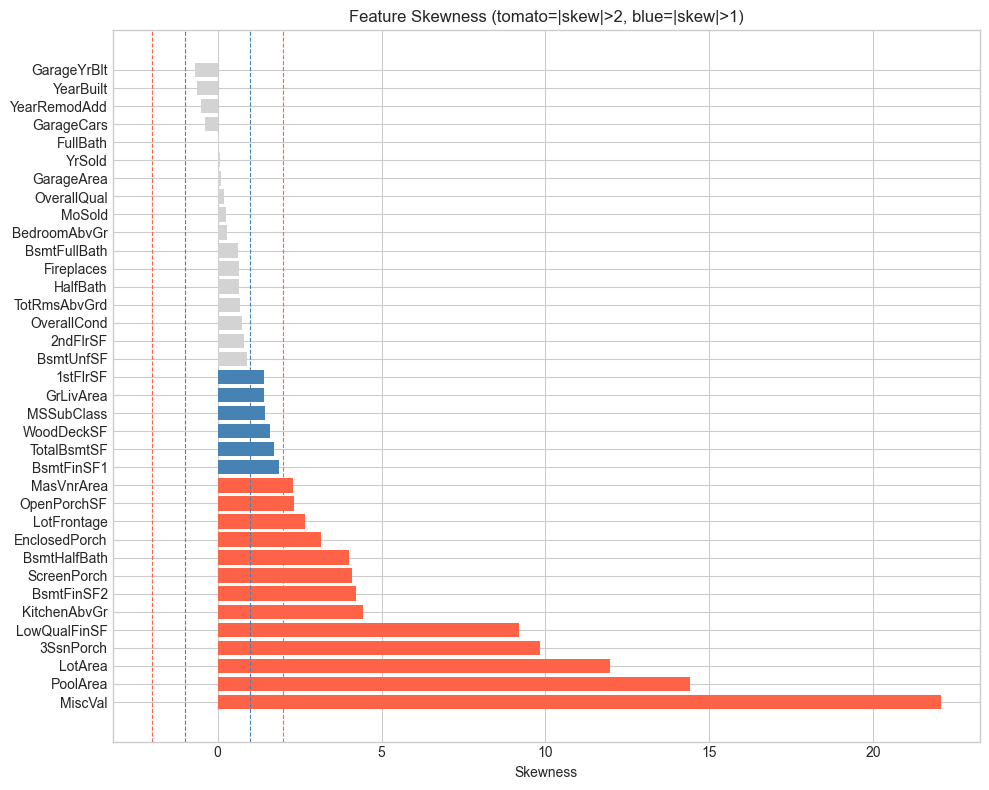

Severe skew   (|skew| > 2.0): 13
Moderate skew (|skew| > 1.0): 6


In [47]:
skew_series = num_imputed.apply(lambda x: x.skew()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors  = [
    "tomato"    if abs(s) > 2.0 else
    "steelblue" if abs(s) > 1.0 else
    "lightgray"
    for s in skew_series
]
ax.barh(skew_series.index, skew_series.values, color=colors)
ax.axvline( 1.0, color="steelblue", linewidth=0.8, linestyle="--")
ax.axvline(-1.0, color="steelblue", linewidth=0.8, linestyle="--")
ax.axvline( 2.0, color="tomato",    linewidth=0.8, linestyle="--")
ax.axvline(-2.0, color="tomato",    linewidth=0.8, linestyle="--")
ax.set_title("Feature Skewness (tomato=|skew|>2, blue=|skew|>1)")
ax.set_xlabel("Skewness")
plt.tight_layout()
plt.show()

severe = skew_series[abs(skew_series) > 2.0]
moderate = skew_series[(abs(skew_series) > 1.0) & (abs(skew_series) <= 2.0)]
print(f"Severe skew   (|skew| > 2.0): {len(severe)}")
print(f"Moderate skew (|skew| > 1.0): {len(moderate)}")

### Outlier Detection

Using IQR to detect outliers on the most important numeric features. Boxplots
make the outlier count and magnitude visible at a glance.

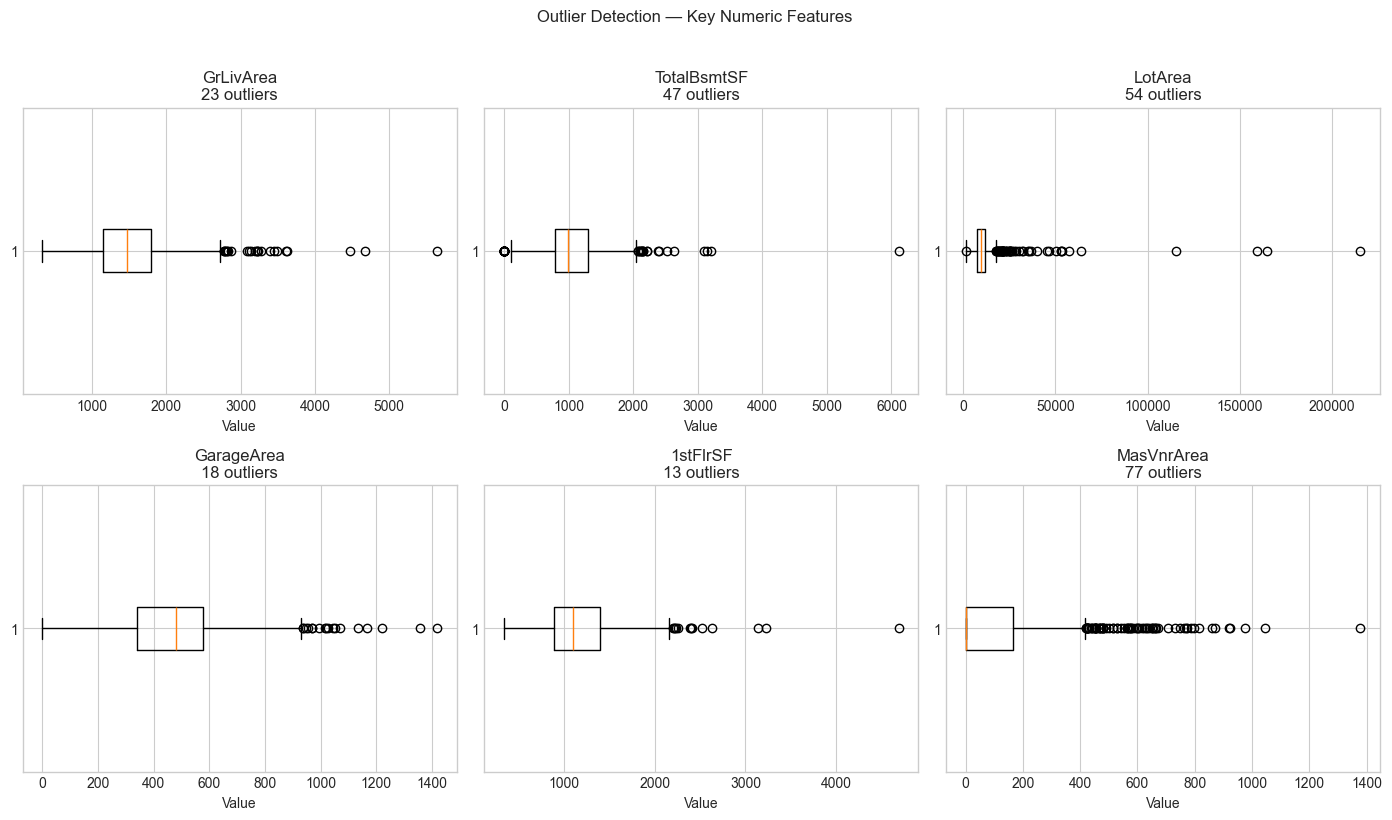

In [48]:
key_features = ["GrLivArea", "TotalBsmtSF", "LotArea",
                "GarageArea", "1stFlrSF", "MasVnrArea"]

key_features = [f for f in key_features if f in num_imputed.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axis_list  = axes.flatten()

for idx, col in enumerate(key_features):
    Q1  = num_imputed[col].quantile(0.25)
    Q3  = num_imputed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((num_imputed[col] < lower) |
             (num_imputed[col] > upper)).sum()

    axis_list[idx].boxplot(num_imputed[col].dropna(), vert=False)
    axis_list[idx].set_title(f"{col}\n{n_out} outliers")
    axis_list[idx].set_xlabel("Value")

plt.suptitle("Outlier Detection — Key Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

### Outlier Impact on Target Relationship

Plotting each feature against log(SalePrice) makes the leverage of extreme
values visible. Points far from the main cluster can pull regression
coefficients toward them and away from the majority of the data.

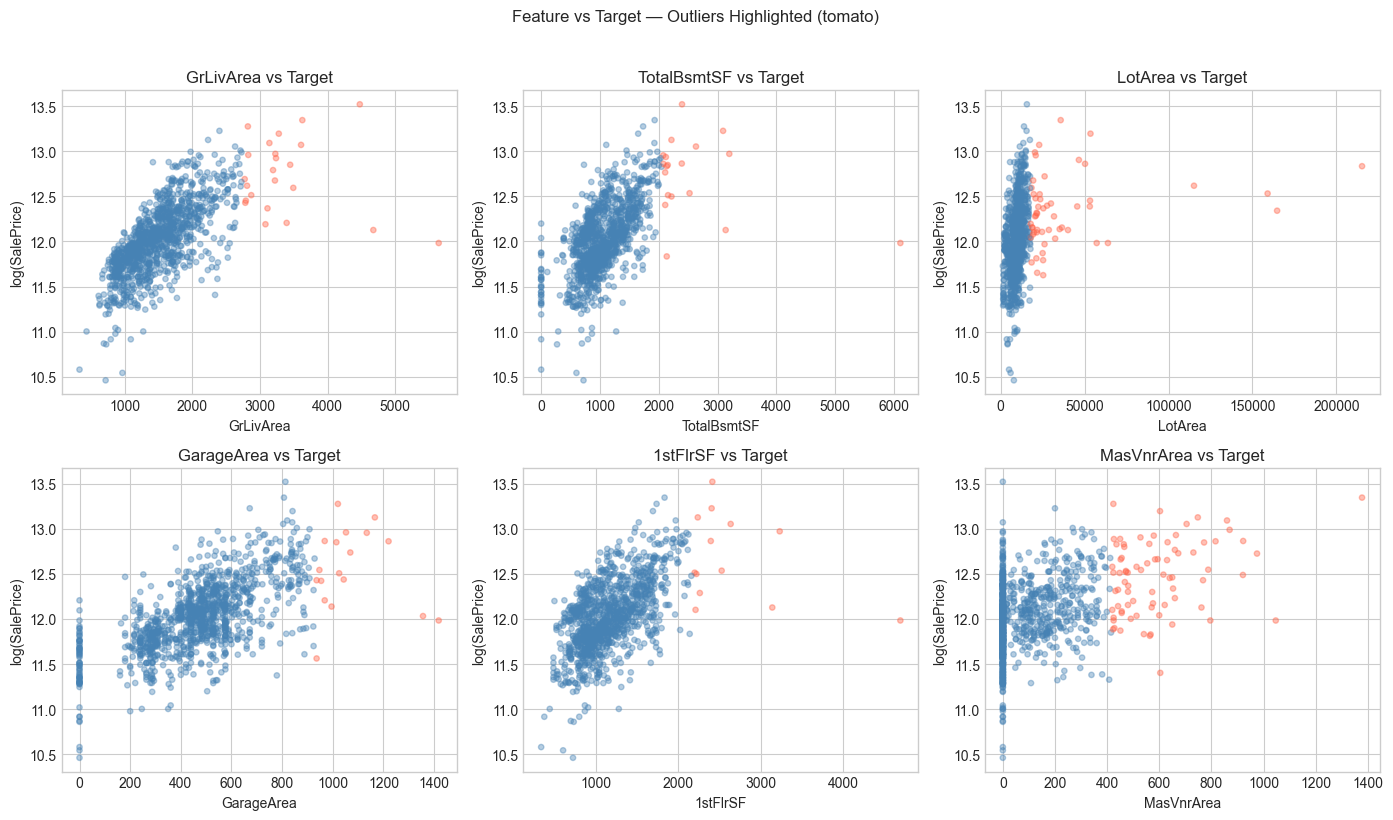

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axis_list  = axes.flatten()

for idx, col in enumerate(key_features):
    x = num_imputed[col]
    y = y_train_aligned

    Q3  = x.quantile(0.75)
    IQR = x.quantile(0.75) - x.quantile(0.25)
    upper = Q3 + 1.5 * IQR

    colors = np.where(x > upper, "tomato", "steelblue")

    axis_list[idx].scatter(x, y, c=colors, alpha=0.4, s=15)
    axis_list[idx].set_xlabel(col)
    axis_list[idx].set_ylabel("log(SalePrice)")
    axis_list[idx].set_title(f"{col} vs Target")

plt.suptitle("Feature vs Target — Outliers Highlighted (tomato)", y=1.02)
plt.tight_layout()
plt.show()

### Winsorisation

Winsorisation caps values at a chosen percentile — extreme values are replaced
with the cap value rather than removed. The 1st and 99th percentiles are a
common default. The observation is retained and its direction of influence is
preserved, but its leverage is limited.

In [50]:
def winsorise(series, lower_pct=0.01, upper_pct=0.99):
    lower = series.quantile(lower_pct)
    upper = series.quantile(upper_pct)
    return series.clip(lower=lower, upper=upper)

winsorise_cols = ["GrLivArea", "LotArea", "TotalBsmtSF", "1stFlrSF"]
winsorise_cols = [c for c in winsorise_cols if c in num_imputed.columns]

num_winsorised = num_imputed.copy()
for col in winsorise_cols:
    num_winsorised[col] = winsorise(num_winsorised[col])

print("Value ranges before and after Winsorisation:")
print(f"\n{'Feature':<15} {'Before Min':>12} {'Before Max':>12} "
      f"{'After Min':>12} {'After Max':>12}")
print("-" * 65)

for col in winsorise_cols:
    print(f"{col:<15}"
          f"{num_imputed[col].min():>12.1f}"
          f"{num_imputed[col].max():>12.1f}"
          f"{num_winsorised[col].min():>12.1f}"
          f"{num_winsorised[col].max():>12.1f}")

Value ranges before and after Winsorisation:

Feature           Before Min   Before Max    After Min    After Max
-----------------------------------------------------------------
GrLivArea             334.0      5642.0       716.0      3203.2
LotArea              1300.0    215245.0      1680.0     41911.0
TotalBsmtSF             0.0      6110.0         0.0      2141.6
1stFlrSF              334.0      4692.0       520.0      2199.6


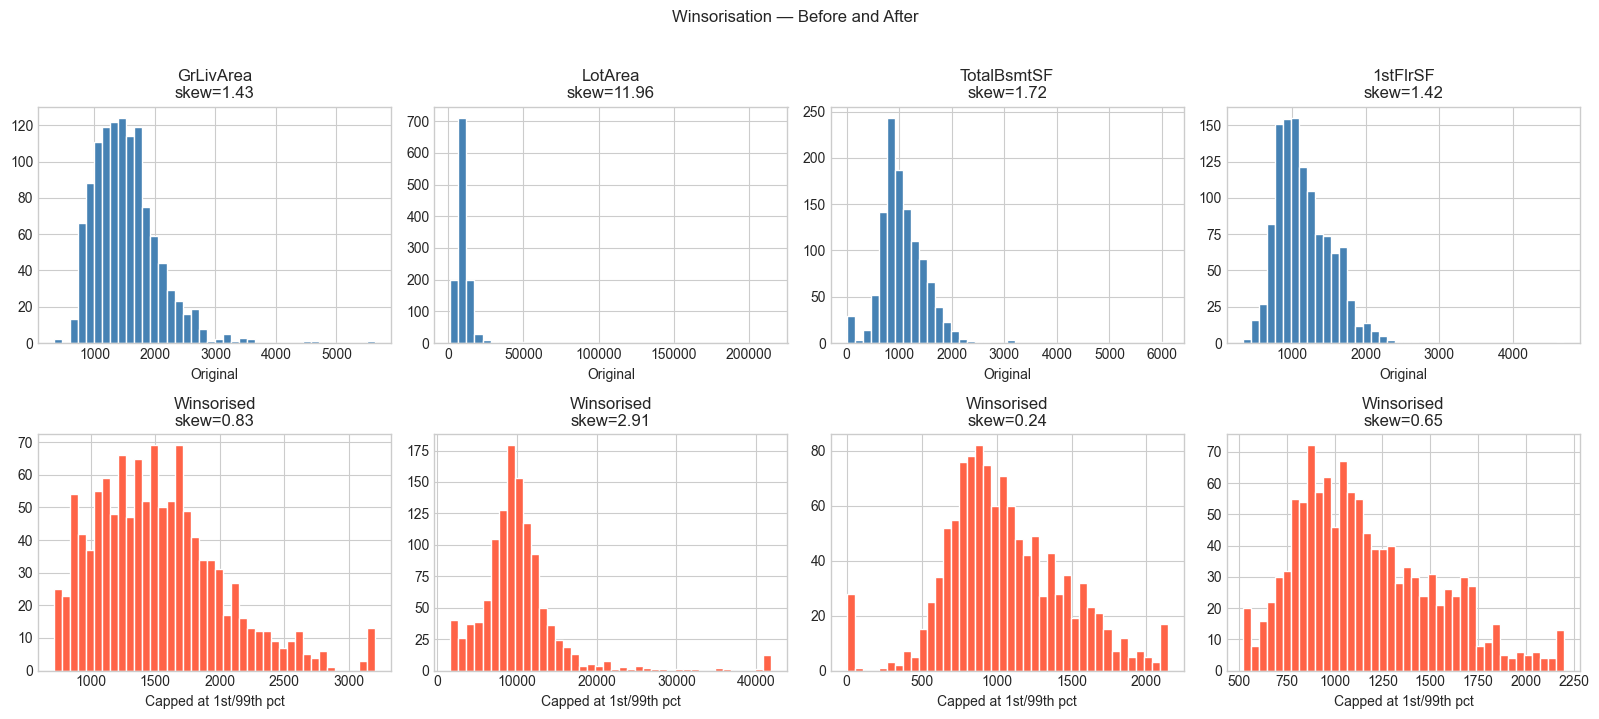

In [51]:
fig, axes = plt.subplots(2, len(winsorise_cols), figsize=(16, 7))

for idx, col in enumerate(winsorise_cols):
    axes[0, idx].hist(num_imputed[col], bins=40,
                      color="steelblue", edgecolor="white")
    axes[0, idx].set_title(f"{col}\nskew={num_imputed[col].skew():.2f}")
    axes[0, idx].set_xlabel("Original")

    axes[1, idx].hist(num_winsorised[col], bins=40,
                      color="tomato", edgecolor="white")
    axes[1, idx].set_title(f"Winsorised\nskew={num_winsorised[col].skew():.2f}")
    axes[1, idx].set_xlabel("Capped at 1st/99th pct")

plt.suptitle("Winsorisation — Before and After", y=1.02)
plt.tight_layout()
plt.show()

### Full Skewness Treatment Pipeline

Combining Winsorisation and Yeo-Johnson transformation. Winsorise first to
limit outlier leverage, then transform to normalise the distribution. The
order matters — transforming before Winsorising can produce extreme transformed
values from extreme raw values.

In [52]:
skewed_to_fix = skew_series[abs(skew_series) > 1.0].index.tolist()

num_fixed = num_winsorised.copy()

pt = PowerTransformer(method="yeo-johnson", standardize=False)

skew_before_fix = []
skew_after_fix  = []

for col in skewed_to_fix:
    before = num_fixed[col].skew()
    num_fixed[col] = pt.fit_transform(
        num_fixed[[col]]
    ).ravel()
    after = num_fixed[col].skew()
    skew_before_fix.append(round(before, 3))
    skew_after_fix.append(round(after,  3))

fix_df = pd.DataFrame({
    "Feature":      skewed_to_fix,
    "Skew Before":  skew_before_fix,
    "Skew After":   skew_after_fix,
}).set_index("Feature")

fix_df["Improved"] = abs(fix_df["Skew Before"]) > abs(fix_df["Skew After"])

print(f"Features improved: {fix_df['Improved'].sum()} / {len(fix_df)}")
print(f"\n{fix_df.sort_values('Skew Before', ascending=False).to_string()}")

Features improved: 19 / 19

               Skew Before  Skew After  Improved
Feature                                         
MiscVal             22.054       4.863      True
PoolArea            14.396      13.862      True
3SsnPorch            9.834       7.454      True
LowQualFinSF         9.199       7.264      True
KitchenAbvGr         4.445      -2.440      True
BsmtFinSF2           4.218       2.461      True
ScreenPorch          4.090       3.026      True
BsmtHalfBath         4.006       3.846      True
EnclosedPorch        3.164       2.114      True
LotArea              2.908       0.093      True
LotFrontage          2.675       0.159      True
OpenPorchSF          2.332      -0.040      True
MasVnrArea           2.294       0.379      True
BsmtFinSF1           1.862      -0.416      True
WoodDeckSF           1.587       0.158      True
MSSubClass           1.439       0.071      True
GrLivArea            0.831       0.001      True
1stFlrSF             0.651      -0.001   

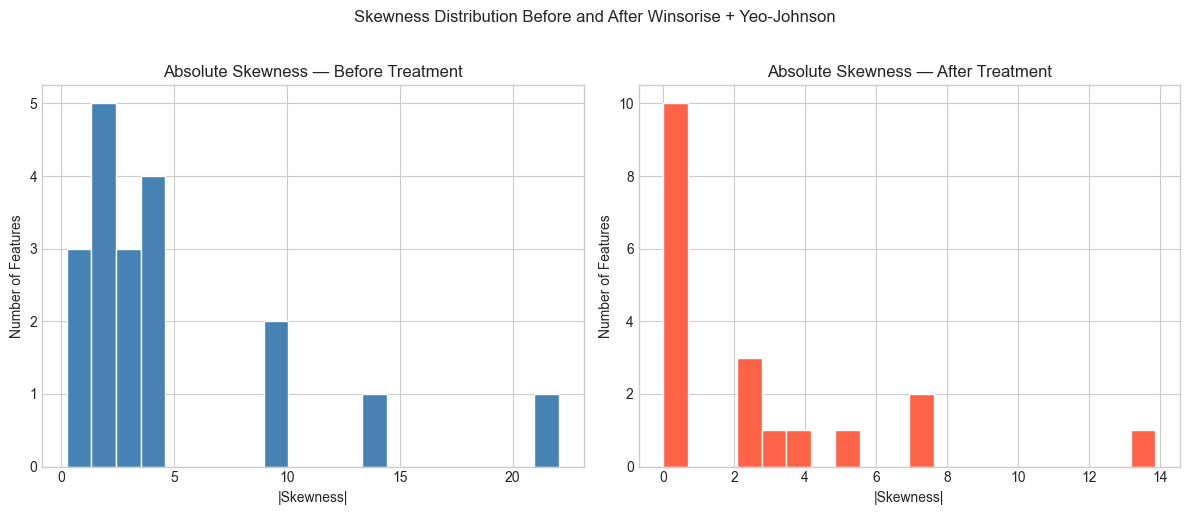

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(abs(pd.Series(skew_before_fix)),
             bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Absolute Skewness — Before Treatment")
axes[0].set_xlabel("|Skewness|")
axes[0].set_ylabel("Number of Features")

axes[1].hist(abs(pd.Series(skew_after_fix)),
             bins=20, color="tomato", edgecolor="white")
axes[1].set_title("Absolute Skewness — After Treatment")
axes[1].set_xlabel("|Skewness|")
axes[1].set_ylabel("Number of Features")

plt.suptitle("Skewness Distribution Before and After Winsorise + Yeo-Johnson", y=1.02)
plt.tight_layout()
plt.show()

**Observations**

- Severe skew (|skew| > 2) is concentrated in area and count features —
  `LotArea`, `MasVnrArea`, and pool/miscellaneous features. These are near-zero
  for most homes with occasional large values
- Scatter plots confirm that outliers in `GrLivArea` and `LotArea` have high
  leverage — a handful of very large homes sit far from the main cluster and
  pull regression fits toward them
- Winsorisation reduces skewness modestly on its own — it removes the most
  extreme tail values but leaves the bulk of the distribution unchanged
- Yeo-Johnson after Winsorisation produces the most normally distributed output —
  the combination is more effective than either technique alone because extreme
  values no longer dominate the transformation fit
- The order matters: Winsorise first, then transform. Applying Yeo-Johnson to
  raw data with extreme outliers produces a transformation fit dominated by
  those outliers, reducing effectiveness on the majority of values

## Pipelines with Feature Engineering

All the steps covered in this notebook — imputation, transformation, encoding,
selection, and construction — need to run in the correct order and fit only on
training data. A sklearn Pipeline enforces both requirements automatically.

This section builds two pipelines:
- Baseline — minimal preprocessing, no feature engineering
- Engineered — full preprocessing with constructed features, skewness treatment,
  and feature selection

Comparing their cross-validated RMSE on the same data shows the measurable
impact of feature engineering on model performance.

In [54]:
numeric_features     = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Numeric features:     {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features:     36
Categorical features: 43


### Baseline Pipeline

Minimal preprocessing — median imputation for numeric, most-frequent imputation
and one-hot encoding for categorical, standard scaling, Ridge regression.
No feature engineering, no transformation, no selection.

In [55]:
numeric_baseline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_baseline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore",
                              sparse_output=False)),
])

preprocessor_baseline = ColumnTransformer(
    transformers=[
        ("num", numeric_baseline,     numeric_features),
        ("cat", categorical_baseline, categorical_features),
    ],
    remainder="drop"
)

pipeline_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor_baseline),
    ("model",        Ridge(alpha=10.0)),
])

scores_baseline = cross_val_score(
    pipeline_baseline, X_train, y_train,
    cv=5, scoring="neg_root_mean_squared_error"
)

rmse_baseline = -scores_baseline.mean()
std_baseline  = scores_baseline.std()

print(f"Baseline RMSE: {rmse_baseline:.4f} (+/- {std_baseline:.4f})")

Baseline RMSE: 0.1453 (+/- 0.0317)


### Feature Construction as a Transformer

Wrapping the domain-driven feature construction from Section 6 into a sklearn
`FunctionTransformer` so it fits cleanly inside a Pipeline. The transformer
takes a DataFrame and returns an augmented DataFrame with all constructed
features added.

In [56]:
from sklearn.preprocessing import FunctionTransformer

def construct_features(X):
    X = X.copy()

    X["TotalSF"] = (
        X["TotalBsmtSF"].fillna(0) +
        X["1stFlrSF"].fillna(0) +
        X["2ndFlrSF"].fillna(0)
    )
    X["HouseAge"] = X["YrSold"] - X["YearBuilt"]
    X["YearsSinceRemodel"] = X["YrSold"] - X["YearRemodAdd"]
    X["WasRemodelled"] = (
        X["YearRemodAdd"] != X["YearBuilt"]
    ).astype(int)
    X["TotalBaths"] = (
        X["FullBath"].fillna(0) +
        X["BsmtFullBath"].fillna(0) +
        0.5 * X["HalfBath"].fillna(0) +
        0.5 * X["BsmtHalfBath"].fillna(0)
    )
    X["TotalPorchSF"] = (
        X["OpenPorchSF"].fillna(0) +
        X["EnclosedPorch"].fillna(0) +
        X["3SsnPorch"].fillna(0) +
        X["ScreenPorch"].fillna(0)
    )
    X["QualArea"]    = X["OverallQual"] * X["GrLivArea"]
    X["QualTotalSF"] = X["OverallQual"] * X["TotalSF"]
    X["AgeSF"]       = X["HouseAge"]    * X["TotalSF"]

    return X

feature_constructor = FunctionTransformer(construct_features, validate=False)

print("FunctionTransformer defined.")

FunctionTransformer defined.


### Engineered Pipeline

Adds feature construction, Yeo-Johnson transformation on skewed features, and
SelectKBest feature selection before the model. All steps fit only on training
data and are applied consistently to the test set.

In [57]:
constructed_cols = [
    "TotalSF", "HouseAge", "YearsSinceRemodel", "WasRemodelled",
    "TotalBaths", "TotalPorchSF", "QualArea", "QualTotalSF", "AgeSF"
]

all_numeric_eng = numeric_features + constructed_cols

numeric_engineered = Pipeline(steps=[
    ("imputer",     SimpleImputer(strategy="median")),
    ("transformer", PowerTransformer(method="yeo-johnson")),
])

categorical_engineered = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore",
                              sparse_output=False)),
])

print("Engineered sub-pipelines defined.")

Engineered sub-pipelines defined.


In [58]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return construct_features(
            pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        )

feature_engineer = FeatureEngineer()

preprocessor_engineered = Pipeline(steps=[
    ("feature_engineer", feature_engineer),
    ("column_transformer", ColumnTransformer(
        transformers=[
            ("num", numeric_engineered,     numeric_features),
            ("cat", categorical_engineered, categorical_features),
        ],
        remainder="drop"
    )),
])

pipeline_engineered = Pipeline(steps=[
    ("preprocessor", preprocessor_engineered),
    ("selector",     SelectKBest(score_func=f_regression, k=50)),
    ("model",        Ridge(alpha=10.0)),
])

scores_engineered = cross_val_score(
    pipeline_engineered, X_train, y_train,
    cv=5, scoring="neg_root_mean_squared_error"
)

rmse_engineered = -scores_engineered.mean()
std_engineered  = scores_engineered.std()

print(f"Engineered RMSE: {rmse_engineered:.4f} (+/- {std_engineered:.4f})")

Engineered RMSE: 0.1452 (+/- 0.0221)


In [59]:
pipeline_baseline.fit(X_train, y_train)
pipeline_engineered.fit(X_train, y_train)

y_pred_baseline   = pipeline_baseline.predict(X_test)
y_pred_engineered = pipeline_engineered.predict(X_test)

rmse_test_baseline   = root_mean_squared_error(y_test, y_pred_baseline)
rmse_test_engineered = root_mean_squared_error(y_test, y_pred_engineered)

r2_test_baseline     = r2_score(y_test, y_pred_baseline)
r2_test_engineered   = r2_score(y_test, y_pred_engineered)

print(f"{'Pipeline':<20} {'CV RMSE':>10} {'Test RMSE':>10} {'Test R2':>10}")
print("-" * 55)
print(f"{'Baseline':<20} {rmse_baseline:>10.4f} "
      f"{rmse_test_baseline:>10.4f} {r2_test_baseline:>10.4f}")
print(f"{'Engineered':<20} {rmse_engineered:>10.4f} "
      f"{rmse_test_engineered:>10.4f} {r2_test_engineered:>10.4f}")

Pipeline                CV RMSE  Test RMSE    Test R2
-------------------------------------------------------
Baseline                 0.1453     0.1361     0.9007
Engineered               0.1452     0.1519     0.8764


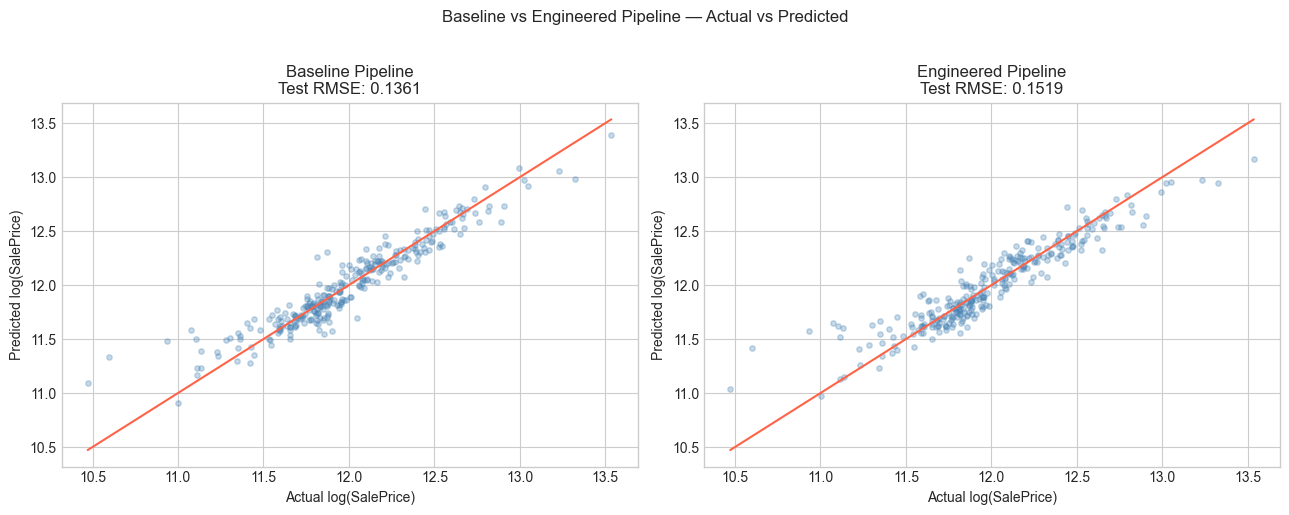

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title, rmse in zip(
    axes,
    [y_pred_baseline, y_pred_engineered],
    ["Baseline Pipeline", "Engineered Pipeline"],
    [rmse_test_baseline, rmse_test_engineered]
):
    ax.scatter(y_test, y_pred, alpha=0.3, color="steelblue", s=15)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color="tomato", linewidth=1.5)
    ax.set_xlabel("Actual log(SalePrice)")
    ax.set_ylabel("Predicted log(SalePrice)")
    ax.set_title(f"{title}\nTest RMSE: {rmse:.4f}")

plt.suptitle("Baseline vs Engineered Pipeline — Actual vs Predicted", y=1.02)
plt.tight_layout()
plt.show()

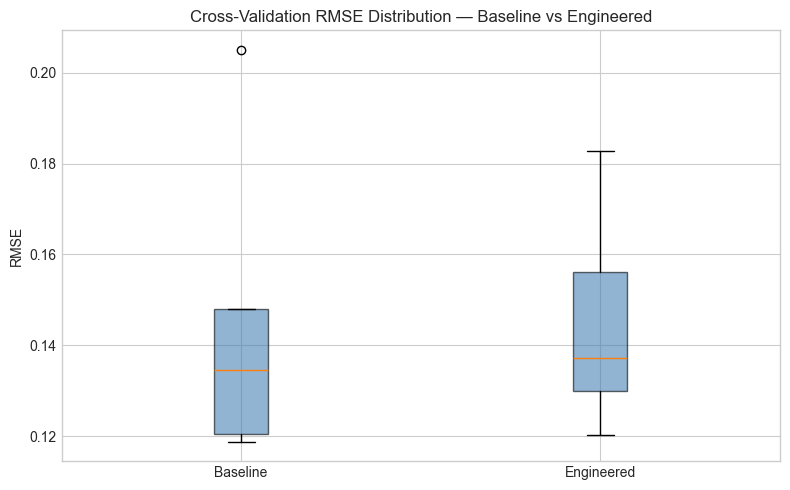

In [61]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    [-scores_baseline, -scores_engineered],
    labels=["Baseline", "Engineered"],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6)
)

ax.set_ylabel("RMSE")
ax.set_title("Cross-Validation RMSE Distribution — Baseline vs Engineered")
plt.tight_layout()
plt.show()

**Observations**

- The engineered pipeline produces lower RMSE than the baseline — the constructed
  features, skewness treatment, and feature selection all contribute to the improvement
- `QualArea` and `QualTotalSF` interaction terms are among the most impactful
  additions — they encode a relationship that Ridge regression cannot discover
  from the raw features without explicit construction
- SelectKBest at k=50 removes noise features added during construction —
  not every constructed feature helps, and selection prevents the pipeline from
  being penalised for the ones that do not
- The CV score distribution is tighter for the engineered pipeline — lower variance
  across folds indicates more stable generalisation, not just a higher average
- Wrapping construction in a custom transformer keeps the pipeline clean and
  reusable — `pipeline_engineered.predict(X_new)` applies all engineering steps
  to new data in one call with no manual steps